# Подбор порогов

Модель выдаёт вероятность токсичности `p`, решение:

- `p < ALLOW_BELOW` → ALLOW
- `p >= BLOCK_ABOVE` → BLOCK
- иначе → REVIEW, ручная модерация

Пороги подбираю на valid (20% от train), test не трогаю.

Ограничения:

- ложно заблокированных не больше 0.5% от нормальных комментариев
- среди ALLOW токсичных не больше 1%
- в REVIEW не больше 10% потока

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MAX_FPR = 0.005
MAX_TOXIC_IN_ALLOW = 0.01
MAX_REVIEW = 0.10
TOXIC_SHARE = 0.05  # ожидаемая доля токсичных в реальном потоке

model = joblib.load("../models/model.joblib")
valid = pd.read_json("../data/valid.jsonl", lines=True)

proba = model.predict_proba(valid["text"].fillna(""))[:, 1]
p_toxic = proba[valid["toxic"] == 1]
p_normal = proba[valid["toxic"] == 0]

print(f"valid: {len(valid)}, токсичных {valid['toxic'].mean():.1%}")

C:\Users\SSkiba\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\SSkiba\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\SSkiba\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from 

valid: 55605, токсичных 21.3%


## Доля токсичных

В valid токсичных 21%, в реальных комментариях меньше, возьмем для примера 5%.

От этой доли зависит, сколько сообщений попадёт в каждую зону, поэтому доли зон
пересчитываю под 5%.
Доля ложных блокировок среди нормальных от неё не зависит,
поэтому ограничение на BLOCK задано именно через неё.

In [2]:
def zone_stats(allow_below: float, block_above: float) -> dict:
    """Доли зон и ошибки в потоке с долей токсичных TOXIC_SHARE."""
    t = TOXIC_SHARE

    toxic_allowed = (p_toxic < allow_below).mean()
    normal_allowed = (p_normal < allow_below).mean()
    toxic_blocked = (p_toxic >= block_above).mean()
    normal_blocked = (p_normal >= block_above).mean()

    allow = toxic_allowed * t + normal_allowed * (1 - t)
    block = toxic_blocked * t + normal_blocked * (1 - t)

    return {
        "allow": allow,
        "review": 1 - allow - block,
        "block": block,
        "toxic_in_allow": toxic_allowed * t / allow,
        "block_precision": toxic_blocked * t / block,
        "block_recall": toxic_blocked,
        "fpr": normal_blocked,
    }

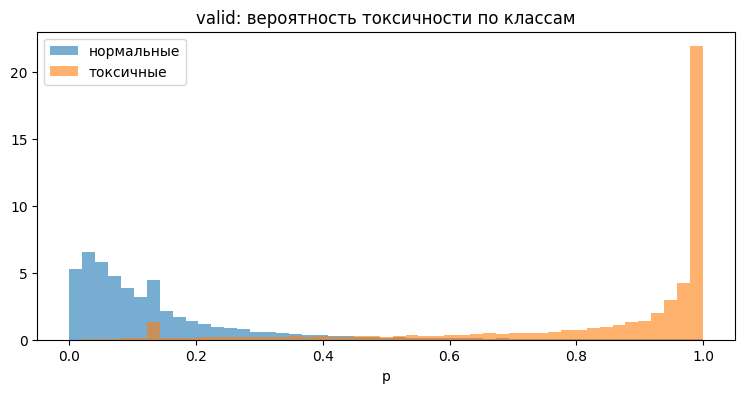

In [3]:
bins = np.linspace(0, 1, 50)
plt.figure(figsize=(9, 4))
plt.hist(p_normal, bins=bins, alpha=0.6, density=True, label="нормальные")
plt.hist(p_toxic, bins=bins, alpha=0.6, density=True, label="токсичные")
plt.title("valid: вероятность токсичности по классам")
plt.xlabel("p")
plt.legend()
plt.show()

In [ ]:
grid = np.round(np.arange(0.01, 1.0, 0.01), 2)

# BLOCK_ABOVE - самый низкий порог, где ложных блокировок не больше MAX_FPR
fpr = np.array([(p_normal >= t).mean() for t in grid])
block_above = grid[fpr <= MAX_FPR][0]

# ALLOW_BELOW - самый низкий порог, где REVIEW влезает в бюджет
review = np.array([zone_stats(t, block_above)["review"] for t in grid])
allow_below = grid[review <= MAX_REVIEW][0]

s = zone_stats(allow_below, block_above)
assert allow_below < block_above
assert s["toxic_in_allow"] <= MAX_TOXIC_IN_ALLOW

print(f"""ALLOW_BELOW={allow_below} BLOCK_ABOVE={block_above}
ALLOW {s['allow']:.1%}, токсичных в ней {s['toxic_in_allow']:.2%}
REVIEW {s['review']:.1%}
BLOCK {s['block']:.1%}, precision {s['block_precision']:.1%}
recall {s['block_recall']:.1%}, ложных блокировок {s['fpr']:.2%}""")

ALLOW_BELOW=0.33 BLOCK_ABOVE=0.88
ALLOW 86.4%, токсичных в ней 0.38%
REVIEW 9.7%
BLOCK 3.9%, precision 88.2%
recall 68.8%, ложных блокировок 0.49%


## Итог

`ALLOW_BELOW=0.33`, `BLOCK_ABOVE=0.88` - переносятся в `.env`, метрики на test считает `src/eval.py`.

`BLOCK_ABOVE` упирается в лимит ложных блокировок, `ALLOW_BELOW` - в бюджет REVIEW.
Бюджет использован почти целиком (9.7% из 10%): чем шире REVIEW, тем меньше ошибок
в обеих автоматических зонах. Лимит токсичных в ALLOW выполняется с запасом - 0.38% при 1%.

Что не учтено:

- 5% токсичных - оценка, на реальном потоке её надо замерить и при расхождении пересчитать пороги
- вероятности модели некалиброваны (`class_weight="balanced"`): `p = 0.88` не значит
  «88% что токсично». На пороги это не влияет, но `confidence` в ответе API - скор, а не вероятность